## Bronx condos (rolling sales)

This notebook mirrors the base condo analysis notebooks, but focuses on **Bronx** condo sales (rows where `BUILDING CLASS CATEGORY` contains `CONDO` and does **not** contain `COOP`).


In [8]:
# install the dependencies (pandas, numpy, openpyxl for .xlsx, ...)
%pip install pandas numpy openpyxl matplotlib seaborn scikit-learn -q

# import the dependencies
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
# Rolling sales by borough: one Excel file per NYC borough under ./data
DATA_DIR = Path("data")

# (display name, filename)
BOROUGH_FILES = [
    ("Bronx", "rollingsales_bronx.xlsx"),
    ("Brooklyn", "rollingsales_brooklyn.xlsx"),
    ("Manhattan", "rollingsales_manhattan.xlsx"),
    ("Queens", "rollingsales_queens.xlsx"),
    ("Staten Island", "rollingsales_statenisland.xlsx"),
]

borough_frames: dict[str, pd.DataFrame] = {}
for borough, fname in BOROUGH_FILES:
    path = DATA_DIR / fname
    # First 4 rows are title/description; real table header starts on row 5
    df = pd.read_excel(path, skiprows=4)
    borough_frames[borough] = df

# Remove any rows where the sale price is 0 or negative or missing
for borough in borough_frames:
    df = borough_frames[borough]
    df = df[df["SALE PRICE"].notna()]
    df = df[df["SALE PRICE"] > 0]
    borough_frames[borough] = df

# Dropping irrelevant columns
columns_to_drop = ["BOROUGH", "APARTMENT NUMBER", "EASEMENT"]
for borough in borough_frames:
    try:
        borough_frames[borough] = borough_frames[borough].drop(columns=columns_to_drop)
    except KeyError:
        pass

sales = pd.concat(borough_frames.values(), ignore_index=True)
print("Combined sales shape:", sales.shape)


Combined sales shape: (53956, 18)


In [10]:
# How empty is each column in each borough? + simple unit imputation

def is_nullish(s: pd.Series) -> pd.Series:
    null = s.isna()
    if s.dtype != object and not pd.api.types.is_string_dtype(s):
        return null
    empty_str = s.map(lambda x: isinstance(x, str) and x.strip() == "")
    return null | empty_str

# Fill in missing values for residential, commercial, and total units
for borough in borough_frames:
    df = borough_frames[borough]
    for idx, row in df.iterrows():
        residential_units = row["RESIDENTIAL UNITS"]
        commercial_units = row["COMMERCIAL UNITS"]
        total_units = row["TOTAL UNITS"]

        r_ok = pd.notna(residential_units) and not (
            isinstance(residential_units, str) and residential_units.strip() == ""
        )
        c_ok = pd.notna(commercial_units) and not (
            isinstance(commercial_units, str) and commercial_units.strip() == ""
        )
        t_ok = pd.notna(total_units) and not (
            isinstance(total_units, str) and total_units.strip() == ""
        )

        if not r_ok and t_ok and c_ok:
            residential_units = total_units - commercial_units
        elif not t_ok and r_ok and c_ok:
            total_units = residential_units + commercial_units
        elif not c_ok and t_ok and r_ok:
            commercial_units = total_units - residential_units

        df.loc[idx, "RESIDENTIAL UNITS"] = residential_units
        df.loc[idx, "COMMERCIAL UNITS"] = commercial_units
        df.loc[idx, "TOTAL UNITS"] = total_units

# Rebuild combined frame so later analysis sees imputed unit columns
sales = pd.concat(borough_frames.values(), ignore_index=True)

# Quick missingness report for Bronx only
bx = borough_frames["Bronx"]
print("Bronx column empty fraction:")
for col in bx.columns:
    print(f"{col}: {is_nullish(bx[col]).mean():.4f}")


Bronx column empty fraction:
NEIGHBORHOOD: 0.0000
BUILDING CLASS CATEGORY: 0.0000
TAX CLASS AT PRESENT: 0.0000
BLOCK: 0.0000
LOT: 0.0000
BUILDING CLASS AT PRESENT: 0.0000
ADDRESS: 0.0000
ZIP CODE: 0.0000
RESIDENTIAL UNITS: 0.2203
COMMERCIAL UNITS: 0.2203
TOTAL UNITS: 0.2203
LAND SQUARE FEET: 0.3091
GROSS SQUARE FEET: 0.3091
YEAR BUILT: 0.0970
TAX CLASS AT TIME OF SALE: 0.0000
BUILDING CLASS AT TIME OF SALE: 0.0000
SALE PRICE: 0.0000
SALE DATE: 0.0000


In [11]:
# Bronx condos (exclude categories that also contain COOP, e.g. CONDO COOPS)
_bcc = borough_frames["Bronx"]["BUILDING CLASS CATEGORY"].astype(str).str.upper()
bronx_condos = borough_frames["Bronx"][_bcc.str.contains("CONDO") & ~_bcc.str.contains("COOP")].copy()

print("Total number of condo sales (Bronx, CONDO & ~COOP):")
print(bronx_condos.shape[0])

print("Building class categories:")
print(pd.Series(bronx_condos["BUILDING CLASS CATEGORY"].unique()).sort_values().to_list())

print("Columns:")
print(bronx_condos.columns)


Total number of condo sales (Bronx, CONDO & ~COOP):
380
Building class categories:
['04 TAX CLASS 1 CONDOS', '11 SPECIAL CONDO BILLING LOTS', '12 CONDOS - WALKUP APARTMENTS', '13 CONDOS - ELEVATOR APARTMENTS', '15 CONDOS - 2-10 UNIT RESIDENTIAL', '16 CONDOS - 2-10 UNIT WITH COMMERCIAL UNIT', '28 COMMERCIAL CONDOS', '42 CONDO CULTURAL/MEDICAL/EDUCATIONAL/ETC', '44 CONDO PARKING', '46 CONDO STORE BUILDINGS']
Columns:
Index(['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT',
       'BLOCK', 'LOT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'ZIP CODE',
       'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
       'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
       'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE',
       'SALE PRICE', 'SALE DATE'],
      dtype='str')


In [12]:
# Drop all-null columns in this slice, then drop LAND/GROSS SF (matches other base condo notebooks)
print("All-null columns in Bronx condo slice:")
print(bronx_condos.columns[bronx_condos.isna().all()])

bronx_condos = bronx_condos.dropna(axis=1, how="all")

print("Null fraction in Bronx condo slice:")
for col in bronx_condos.columns:
    print(f"{col}: {bronx_condos[col].isna().mean():.4f}")

for c in ("LAND SQUARE FEET", "GROSS SQUARE FEET"):
    if c in bronx_condos.columns:
        bronx_condos = bronx_condos.drop(columns=[c])

bronx_condos.head()


All-null columns in Bronx condo slice:
Index([], dtype='str')
Null fraction in Bronx condo slice:
NEIGHBORHOOD: 0.0000
BUILDING CLASS CATEGORY: 0.0000
TAX CLASS AT PRESENT: 0.0000
BLOCK: 0.0000
LOT: 0.0000
BUILDING CLASS AT PRESENT: 0.0000
ADDRESS: 0.0000
ZIP CODE: 0.0000
RESIDENTIAL UNITS: 0.0000
COMMERCIAL UNITS: 0.0000
TOTAL UNITS: 0.0000
LAND SQUARE FEET: 0.9947
GROSS SQUARE FEET: 0.9947
YEAR BUILT: 0.5974
TAX CLASS AT TIME OF SALE: 0.0000
BUILDING CLASS AT TIME OF SALE: 0.0000
SALE PRICE: 0.0000
SALE DATE: 0.0000


,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,BUILDING CLASS AT PRESENT,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
392,BAYCHESTER,04 TAX CLASS 1 CONDOS,1A,4795,1027,R3,"2853 ELY AVENUE, 3",10469,1.0,0.0,1.0,2008.0,1,R3,465000,2026-01-22
393,BAYCHESTER,04 TAX CLASS 1 CONDOS,1A,4795,1041,R3,"2833 ELY AVENUE, 2",10469,1.0,0.0,1.0,2008.0,1,R3,472000,2025-03-10
394,BAYCHESTER,04 TAX CLASS 1 CONDOS,1A,4939,1004,R3,"3703 PRATT AVENUE, 1B",10466,1.0,0.0,1.0,2013.0,1,R3,444000,2025-07-28
395,BAYCHESTER,04 TAX CLASS 1 CONDOS,1A,4939,1007,R3,"3705 PRATT AVENUE, 1C",10466,1.0,0.0,1.0,2013.0,1,R3,510000,2025-10-15
455,BAYCHESTER,44 CONDO PARKING,4,4795,1046,RG,"2853 ELY AVENUE, GA4",10469,0.0,1.0,1.0,2008.0,4,RG,465000,2026-01-22


In [13]:
# Time & place: walkup vs elevator, neighborhood, vintage (condo slice)
REF_YEAR = 2026

b = borough_frames["Bronx"].copy()
_bcc = b["BUILDING CLASS CATEGORY"].astype(str).str.upper()
condo_tp = b[_bcc.str.contains("CONDO") & ~_bcc.str.contains("COOP")].copy()

condo_tp["SALE DATE"] = pd.to_datetime(condo_tp["SALE DATE"])

bcc_upper = condo_tp["BUILDING CLASS CATEGORY"].astype(str).str.upper()
condo_tp["BUILDING_STYLE"] = np.where(
    bcc_upper.str.contains("WALKUP"),
    "Walkup",
    np.where(bcc_upper.str.contains("ELEVATOR"), "Elevator", "Other"),
)

condo_tp["YEAR BUILT"] = pd.to_numeric(condo_tp["YEAR BUILT"], errors="coerce")
condo_tp["BUILDING_AGE"] = REF_YEAR - condo_tp["YEAR BUILT"]

# Upper-tail IQR trim on sale price (keeps bulk of distribution, drops extreme outliers)
q1 = condo_tp["SALE PRICE"].quantile(0.25)
q3 = condo_tp["SALE PRICE"].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
condo_tp = condo_tp[condo_tp["SALE PRICE"] < upper_fence].copy()

condo_tp["YEAR"] = condo_tp["SALE DATE"].dt.year
condo_tp["MONTH"] = condo_tp["SALE DATE"].dt.month
condo_tp["YEAR_MONTH"] = condo_tp["SALE DATE"].dt.to_period("M")
condo_tp["QUARTER"] = condo_tp["SALE DATE"].dt.to_period("Q")

print("BUILDING_STYLE counts:\n", condo_tp["BUILDING_STYLE"].value_counts(), sep="")
print(f"\nRows after upper IQR trim: {len(condo_tp):,}")
print(f"Sale date range: {condo_tp['SALE DATE'].min().date()} – {condo_tp['SALE DATE'].max().date()}")
print(f"Neighborhoods: {condo_tp['NEIGHBORHOOD'].nunique()}")


BUILDING_STYLE counts:
BUILDING_STYLE
Elevator    258
Other        86
Walkup        7
Name: count, dtype: int64

Rows after upper IQR trim: 351
Sale date range: 2025-03-05 – 2026-02-27
Neighborhoods: 14


In [14]:
# Comparable outcomes: total sale price vs price per residential unit; deal scope; BCC segment
ru = pd.to_numeric(condo_tp["RESIDENTIAL UNITS"], errors="coerce")
sp = condo_tp["SALE PRICE"].astype(float)
condo_tp["PRICE_PER_RES_UNIT"] = np.where(ru > 0, sp / ru, np.nan)
condo_tp["DEAL_SCOPE"] = np.where(
    ru.isna() | (ru <= 0),
    "Unknown/missing units",
    np.where(ru == 1, "Single unit (likely apartment sale)", "Multi-unit / bulk"),
)

bcc = condo_tp["BUILDING CLASS CATEGORY"].astype(str).str.upper()
cond_special = bcc.str.contains("SPECIAL CONDO BILLING")
cond_comm = bcc.str.contains(
    "CONDO STORE|CONDO OFFICE|CONDO HOTEL|COMMERCIAL CONDO|CONDO PARKING|WAREHOUSE|FACTORY|"
    "NON-BUSINESS STORAGE|TERRACES|CULTURAL|MEDICAL|EDUCATIONAL"
)
cond_res = bcc.str.contains("WALKUP|ELEVATOR|2-10 UNIT|TAX CLASS 1 CONDOS")
condo_tp["BCC_SEGMENT"] = np.select(
    [cond_special, cond_comm, cond_res],
    ["Special billing lots", "Commercial / non-housing", "Residential (walkup/elevator/small)"],
    default="Other / unclassified",
)

print("DEAL_SCOPE:\n", condo_tp["DEAL_SCOPE"].value_counts(), sep="")
print("\nBCC_SEGMENT:\n", condo_tp["BCC_SEGMENT"].value_counts(), sep="")


DEAL_SCOPE:
DEAL_SCOPE
Single unit (likely apartment sale)    338
Unknown/missing units                   13
Name: count, dtype: int64

BCC_SEGMENT:
BCC_SEGMENT
Residential (walkup/elevator/small)    338
Commercial / non-housing                13
Name: count, dtype: int64


/var/folders/zp/x9j0szyd697b0byr_q5hdqd80000gn/T/ipykernel_19740/2170511917.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=condo_tp, x="BUILDING_STYLE", y="SALE PRICE", showfliers=False, ax=ax, palette="pastel")
/var/folders/zp/x9j0szyd697b0byr_q5hdqd80000gn/T/ipykernel_19740/2170511917.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=condo_tp, x="BCC_SEGMENT", y="SALE PRICE", showfliers=False, ax=ax, palette="muted")


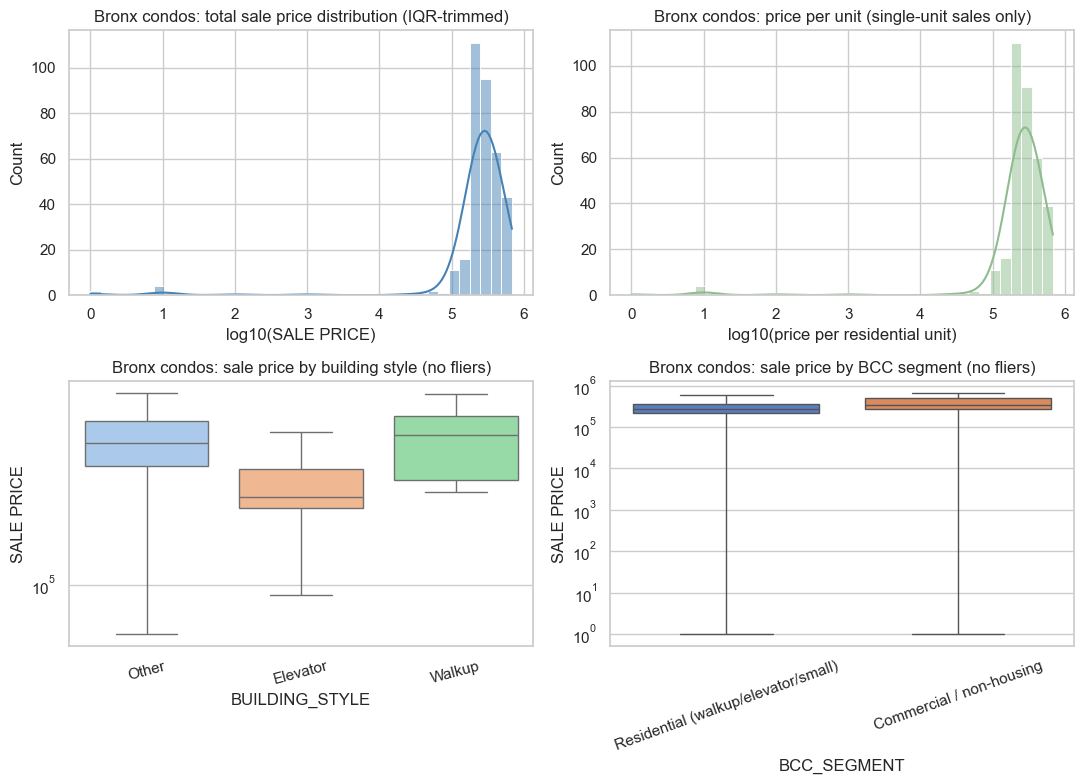

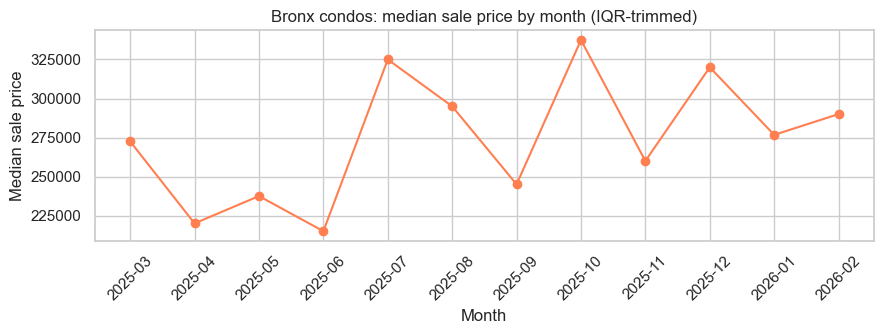

In [15]:
# Visualizations (Bronx condos)
# Note: prices are highly skewed, so we use log scales for readability.

sns.set_theme(style="whitegrid", context="notebook")

single = condo_tp[condo_tp["DEAL_SCOPE"] == "Single unit (likely apartment sale)"].copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
sns.histplot(np.log10(condo_tp["SALE PRICE"]), bins=40, kde=True, ax=ax, color="steelblue")
ax.set_xlabel("log10(SALE PRICE)")
ax.set_title("Bronx condos: total sale price distribution (IQR-trimmed)")

ax = axes[0, 1]
su = single["PRICE_PER_RES_UNIT"].dropna()
if len(su) > 0:
    sns.histplot(np.log10(su), bins=40, kde=True, ax=ax, color="darkseagreen")
    ax.set_xlabel("log10(price per residential unit)")
    ax.set_title("Bronx condos: price per unit (single-unit sales only)")
else:
    ax.set_title("Bronx condos: no single-unit rows")

ax = axes[1, 0]
sns.boxplot(data=condo_tp, x="BUILDING_STYLE", y="SALE PRICE", showfliers=False, ax=ax, palette="pastel")
ax.set_yscale("log")
ax.set_title("Bronx condos: sale price by building style (no fliers)")
ax.tick_params(axis="x", rotation=15)

ax = axes[1, 1]
sns.boxplot(data=condo_tp, x="BCC_SEGMENT", y="SALE PRICE", showfliers=False, ax=ax, palette="muted")
ax.set_yscale("log")
ax.set_title("Bronx condos: sale price by BCC segment (no fliers)")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Time: monthly median price (short window — interpret as seasonal/noisy, not long-run trend)
monthly = (
    condo_tp.groupby("YEAR_MONTH", sort=True)["SALE PRICE"]
    .median()
    .reset_index(name="median_price")
)
monthly["YEAR_MONTH"] = monthly["YEAR_MONTH"].astype(str)

fig2, ax2 = plt.subplots(figsize=(9, 3.5))
ax2.plot(monthly["YEAR_MONTH"], monthly["median_price"], marker="o", color="coral")
ax2.set_ylabel("Median sale price")
ax2.set_xlabel("Month")
ax2.set_title("Bronx condos: median sale price by month (IQR-trimmed)")
ax2.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


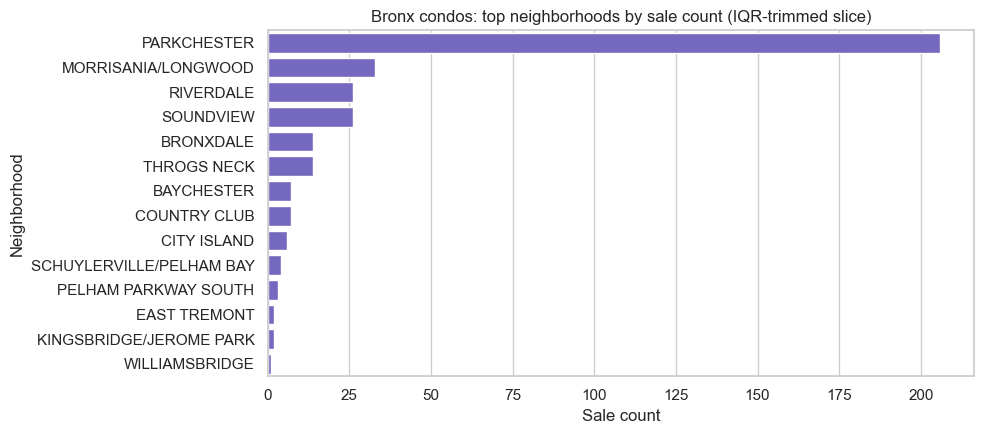

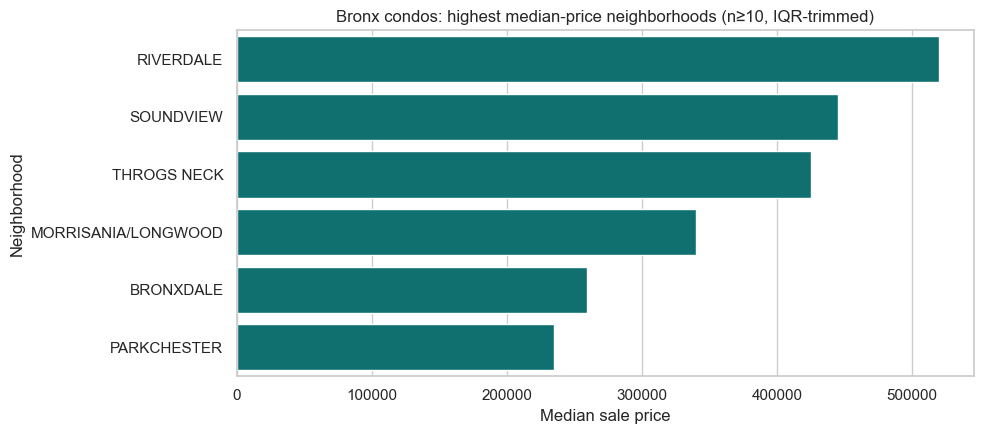

In [16]:
# Neighborhood / ZIP snapshots

# Top neighborhoods by number of condo sales
nbh_counts = condo_tp["NEIGHBORHOOD"].astype(str).value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(x=nbh_counts.values, y=nbh_counts.index, ax=ax, color="slateblue")
ax.set_title("Bronx condos: top neighborhoods by sale count (IQR-trimmed slice)")
ax.set_xlabel("Sale count")
ax.set_ylabel("Neighborhood")
plt.tight_layout()
plt.show()

# Median sale price by neighborhood (require minimum n to reduce noise)
nbh_stats = (
    condo_tp.groupby("NEIGHBORHOOD")["SALE PRICE"]
    .agg(n="size", median="median")
    .reset_index()
)
nbh_stats = nbh_stats[nbh_stats["n"] >= 10].sort_values("median", ascending=False).head(15)

if len(nbh_stats) > 0:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.barplot(data=nbh_stats, x="median", y="NEIGHBORHOOD", ax=ax, color="teal")
    ax.set_title("Bronx condos: highest median-price neighborhoods (n≥10, IQR-trimmed)")
    ax.set_xlabel("Median sale price")
    ax.set_ylabel("Neighborhood")
    ax.ticklabel_format(style="plain", axis="x")
    plt.tight_layout()
    plt.show()
else:
    print("No neighborhoods have n ≥ 10 in this trimmed slice.")
